# EDA – Credit Card Transactions
**Task 1 — Data Analysis and Preprocessing**

---
Contents:
1. Load & inspect
2. Class imbalance
3. Feature distributions
4. Correlation analysis
5. Scaling
6. SMOTE resampling
7. Save processed data


## 1. Load & Inspect

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import os
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid", palette="muted")

RAW  = "../data/raw/"
PROC = "../data/processed/"
os.makedirs(PROC, exist_ok=True)

cc = pd.read_csv(RAW + "creditcard.csv")
print(f"Shape   : {cc.shape}")
print(f"Missing : {cc.isnull().sum().sum()}")
print(f"Dupes   : {cc.duplicated().sum()}")
display(cc.head())
display(cc.describe())


Shape   : (284807, 31)
Missing : 0


Dupes   : 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Class Imbalance

        Count     Pct%
Class                 
0      284315  99.8273
1         492   0.1727


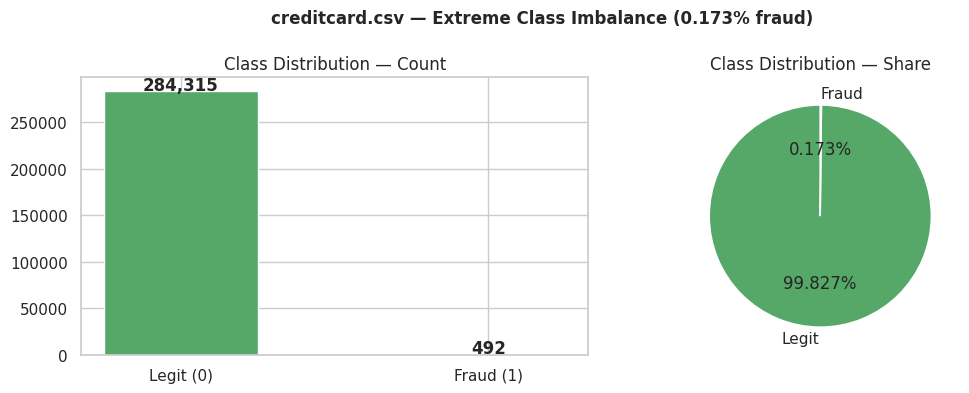

In [2]:
counts = cc["Class"].value_counts()
pct    = cc["Class"].value_counts(normalize=True)*100
print(pd.DataFrame({"Count":counts,"Pct%":pct.round(4)}))

fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].bar(["Legit (0)","Fraud (1)"],counts.values,color=["#55A868","#C44E52"],edgecolor="white",width=0.5)
axes[0].set_title("Class Distribution — Count")
for i,v in enumerate(counts.values):
    axes[0].text(i,v+1000,f"{v:,}",ha="center",fontweight="bold")
axes[1].pie(counts.values,labels=["Legit","Fraud"],colors=["#55A868","#C44E52"],
            autopct="%1.3f%%",startangle=90,wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Class Distribution — Share")
plt.suptitle("creditcard.csv — Extreme Class Imbalance (0.173% fraud)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC+"cc_class_imbalance.png",bbox_inches="tight")
plt.show()


## 3. Feature Distributions

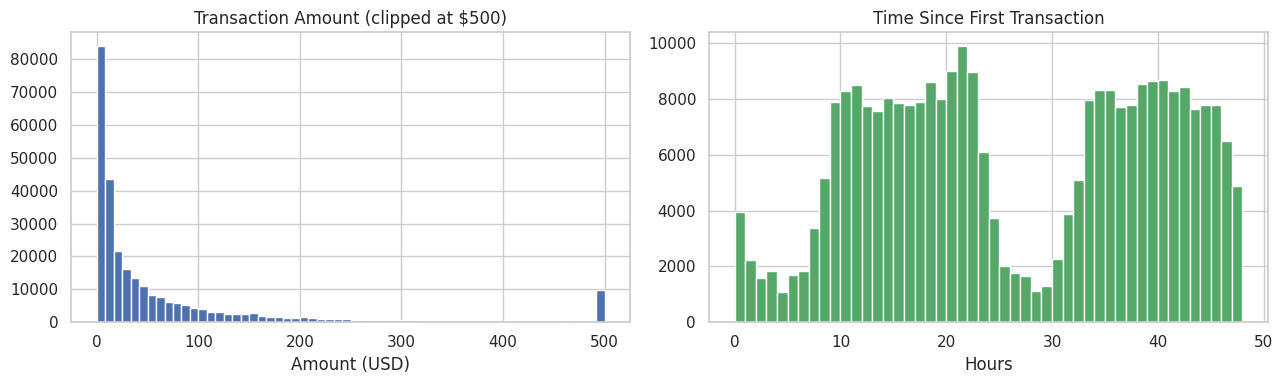

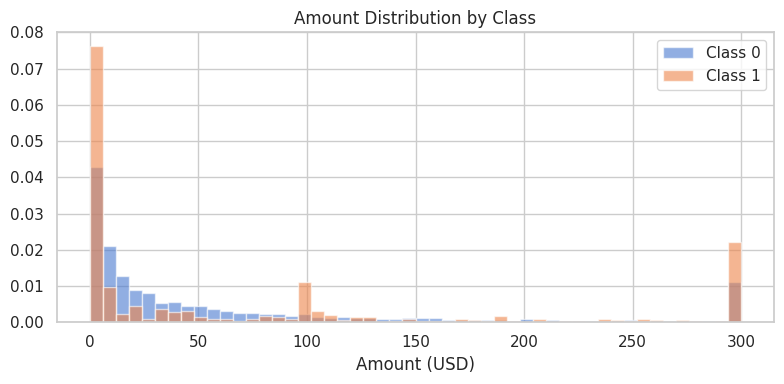

Fraud mean amount  : 122.21
Legit mean amount  : 88.29


In [3]:
# Amount and Time distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cc["Amount"].clip(0,500), bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_title("Transaction Amount (clipped at $500)")
axes[0].set_xlabel("Amount (USD)")

axes[1].hist(cc["Time"]/3600, bins=48, color="#55A868", edgecolor="white")
axes[1].set_title("Time Since First Transaction")
axes[1].set_xlabel("Hours")
plt.tight_layout()
plt.savefig(PROC+"cc_amount_time.png",bbox_inches="tight")
plt.show()

# Amount by class
fig, ax = plt.subplots(figsize=(8,4))
for cls, grp in cc.groupby("Class"):
    ax.hist(grp["Amount"].clip(0,300), bins=50, alpha=0.6,
            label=f"Class {cls}", density=True)
ax.set_title("Amount Distribution by Class")
ax.set_xlabel("Amount (USD)")
ax.legend()
plt.tight_layout()
plt.savefig(PROC+"cc_amount_by_class.png",bbox_inches="tight")
plt.show()
print("Fraud mean amount  :", cc[cc["Class"]==1]["Amount"].mean().round(2))
print("Legit mean amount  :", cc[cc["Class"]==0]["Amount"].mean().round(2))


## 4. Correlation with Target

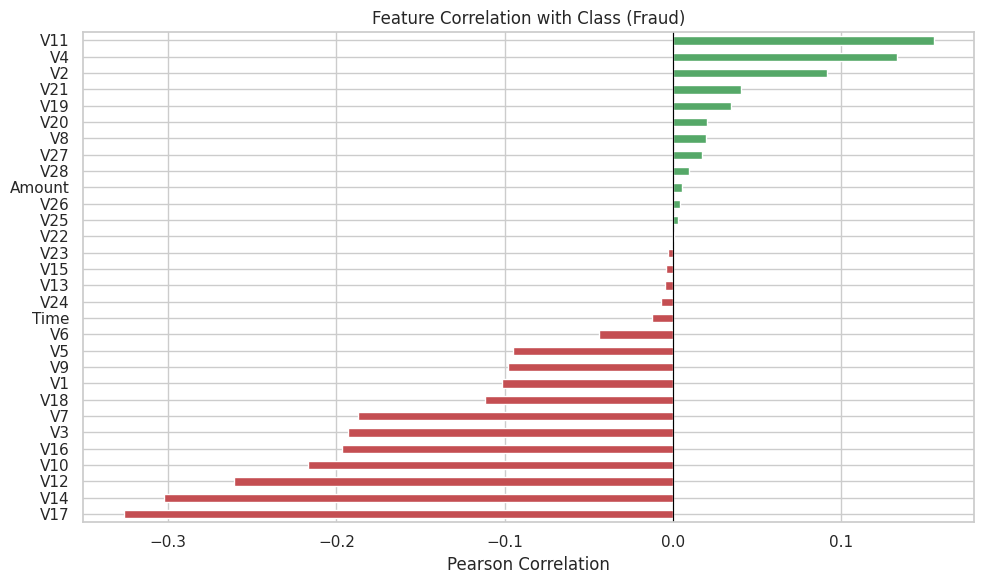

Top positive correlations (fraud signal):
Amount    0.0056
V28       0.0095
V27       0.0176
V8        0.0199
V20       0.0201
V19       0.0348
V21       0.0404
V2        0.0913
V4        0.1334
V11       0.1549
Name: Class, dtype: float64

Top negative correlations:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V18   -0.1115
V1    -0.1013
V9    -0.0977
Name: Class, dtype: float64


In [4]:
correlations = cc.corr()["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(10,6))
correlations.plot(kind="barh", ax=ax,
                  color=["#C44E52" if v<0 else "#55A868" for v in correlations.values])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Class (Fraud)")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig(PROC+"cc_correlations.png",bbox_inches="tight")
plt.show()
print("Top positive correlations (fraud signal):")
print(correlations.tail(10).round(4))
print("\nTop negative correlations:")
print(correlations.head(10).round(4))


## 5. Scaling Amount & Time

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

cc_clean = cc.drop_duplicates().copy()

scaler = StandardScaler()
cc_clean[["Amount","Time"]] = scaler.fit_transform(cc_clean[["Amount","Time"]])

X = cc_clean.drop(columns=["Class"])
y = cc_clean["Class"]
print("Feature shape:", X.shape)


Feature shape: (283726, 30)


## 6. SMOTE Resampling

Before SMOTE:
  Train Legit:226,602  Fraud:378


After SMOTE:
  Train Legit:226,602  Fraud:226,602
  Test  Legit:56,651  Fraud:95


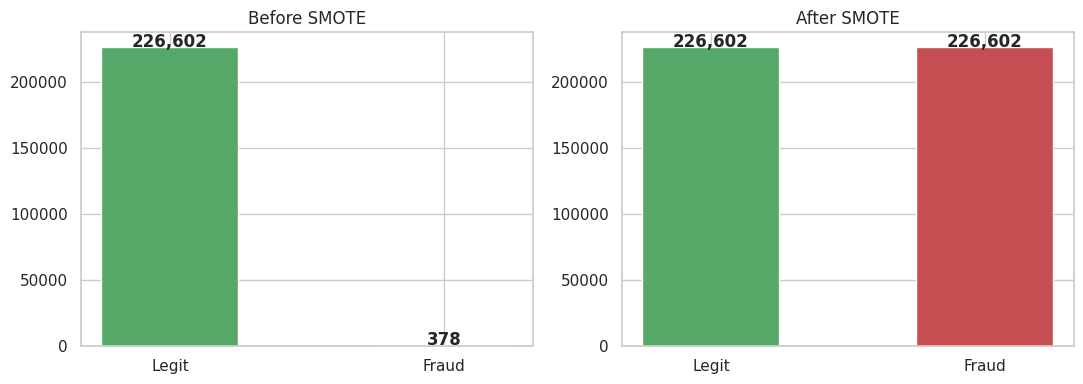

In [6]:
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Before SMOTE:")
print(f"  Train Legit:{(y_train==0).sum():,}  Fraud:{(y_train==1).sum():,}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"  Train Legit:{(y_train_res==0).sum():,}  Fraud:{(y_train_res==1).sum():,}")
print(f"  Test  Legit:{(y_test==0).sum():,}  Fraud:{(y_test==1).sum():,}")

fig, axes = plt.subplots(1,2,figsize=(11,4))
for ax,(y_,title) in zip(axes,[(y_train,"Before SMOTE"),(y_train_res,"After SMOTE")]):
    c = y_.value_counts()
    ax.bar(["Legit","Fraud"],c.values,color=["#55A868","#C44E52"],edgecolor="white",width=0.5)
    ax.set_title(title)
    for i,v in enumerate(c.values):
        ax.text(i,v+500,f"{v:,}",ha="center",fontweight="bold")
plt.tight_layout()
plt.savefig(PROC+"cc_smote.png",bbox_inches="tight")
plt.show()


## 7. Save Processed Data

In [7]:
import joblib
X_train_res.to_csv(PROC+"cc_X_train.csv",index=False)
X_test.to_csv(PROC+"cc_X_test.csv",index=False)
pd.Series(y_train_res,name="Class").to_csv(PROC+"cc_y_train.csv",index=False)
pd.Series(y_test,name="Class").to_csv(PROC+"cc_y_test.csv",index=False)
joblib.dump(scaler,"../models/cc_scaler.pkl")
print("Saved all credit card processed files ✓")


Saved all credit card processed files ✓


## Summary

| Step | Finding |
|---|---|
| Shape | 284,807 transactions, 31 features (V1–V28 + Time, Amount, Class) |
| Missing values | 0 |
| Duplicates | 1,081 removed |
| Class imbalance | 0.173% fraud (492 / 284,807) — extremely skewed |
| Amount signal | Fraud transactions avg $122 vs $88 legit |
| Key correlations | V14, V12, V10, V16 most negatively correlated with fraud |
| SMOTE | Training set balanced: ~227k legit : ~227k fraud |
